In this notebook Seamese network model for handwriting author verification trained. As backbpn ResNet50 used with freezed parameters.

In [1]:
#importing dataset
!pip install -q gdown

file_id = "1YomoMVLtK0WG_GXV_B8Wd5OitzS-ObHi"
output_name = "all_data_2.zip"

!gdown --id {file_id} -O {output_name}

/usr/local/lib/python3.12/dist-packages/gdown/__main__.py:139: FutureWarning: Option `--id` was deprecated in version 4.3.1 and will be removed in 5.0. You don't need to pass it anymore to use a file ID.
  warnings.warn(
Downloading...
From (original): https://drive.google.com/uc?id=1YomoMVLtK0WG_GXV_B8Wd5OitzS-ObHi
From (redirected): https://drive.google.com/uc?id=1YomoMVLtK0WG_GXV_B8Wd5OitzS-ObHi&confirm=t&uuid=4069ca2d-fad3-48be-bc76-079b4e7efabc
To: /kaggle/working/all_data_2.zip
100%|███████████████████████████████████████| 1.71G/1.71G [00:11<00:00, 147MB/s]


In [4]:
import zipfile
import os

with zipfile.ZipFile("all_data_2.zip", 'r') as zip_ref:
    zip_ref.extractall("/kaggle/working/")

# Посмотрите, что получилось
os.listdir("/kaggle/working/")

['all_data_2', 'all_data_2.zip', '.virtual_documents']

In [6]:
DATA_ROOT = "/kaggle/working/all_data_2"

In [7]:
!pip install torchvision

In [8]:
import os
from pathlib import Path
import cv2
import numpy as np
import shutil
import random
import torch

from torch.utils.data import Dataset
import PIL
from PIL import Image
import torchvision.transforms as T
import torchvision.transforms.functional as TF
from torch.utils.data import DataLoader

import torch.nn as nn
import torchvision.models as models
import torch.optim as optim
from torch.optim.lr_scheduler import ReduceLROnPlateau
import torch.nn.functional as F
from sklearn.metrics import roc_auc_score
from tqdm import tqdm
import matplotlib.pyplot as plt
import seaborn as sns


In [9]:
def set_seed(seed=42):
    """Fix all random seeds for reproducibility"""
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    os.environ['PYTHONHASHSEED'] = str(seed)
    print(f"All seeds fixed to {seed}")
set_seed(42)

All seeds fixed to 42


Let's create class SiameseNetworkDataset for our data.
The dataset takes random pairs and create either positive (one author) or negative pair. The labels are created at random, the balance shall be ~50/50.
The pairs are created 'on the fly'.

In [11]:
class SiameseNetworkDataset(Dataset):
    def __init__(self, root, transform=None, train=True, size=100,
                 min_height=50, max_height=500, authors_list=None,
                 cedar_ratio=0.3):
        """
        Dataset for Siamese Network with Contrastive Loss.
        Supports IAM (handwriting lines) and CEDAR (signatures with forgeries).
        
        Args:
            root: Root directory containing 'iam' and 'cedar' folders
            transform: Image transformations
            train: Whether this is training dataset
            size: Number of pairs per epoch
            min_height: Minimum image height filter
            max_height: Maximum image height filter
            authors_list: List of author IDs to include (for train/val split)
            cedar_ratio: Probability of sampling from CEDAR (0.3 = 30% CEDAR, 70% IAM)
        """
        self.transform = transform
        self.train = train
        self.size = size
        self.min_height = min_height
        self.max_height = max_height
        self.cedar_ratio = cedar_ratio
        
        # Data structures
        self.iam_data = {}      # author_path -> list of image paths (IAM)
        self.cedar_original = {} # author_path -> list of original signatures
        self.cedar_forgery = {}  # author_path -> list of forgery signatures
        
        # === Scan IAM folder ===
        iam_path = os.path.join(root, 'iam')
        if os.path.exists(iam_path):
            for folder in os.listdir(iam_path):
                author_path = os.path.join(iam_path, folder)
                if not os.path.isdir(author_path):
                    continue
                
                author_id = folder
                valid_images = []
                for file in os.listdir(author_path):
                    if not file.lower().endswith(('.png', '.jpg', '.jpeg')):
                        continue
                    
                    img_path = os.path.join(author_path, file)
                    try:
                        with Image.open(img_path) as img:
                            height = img.size[1]
                        if self.min_height <= height <= self.max_height:
                            valid_images.append(img_path)
                    except Exception:
                        continue
                
                if valid_images:
                    self.iam_data[author_id] = valid_images
        
        # === Scan CEDAR folder ===
        cedar_path = os.path.join(root, 'cedar')
        if os.path.exists(cedar_path):
            # Original signatures
            original_path = os.path.join(cedar_path, 'original')
            if os.path.exists(original_path):
                for folder in os.listdir(original_path):
                    author_path = os.path.join(original_path, folder)
                    if not os.path.isdir(author_path):
                        continue
                    
                    author_id = folder
                    valid_images = []
                    for file in os.listdir(author_path):
                        if not file.lower().endswith(('.png', '.jpg', '.jpeg')):
                            continue
                        
                        img_path = os.path.join(author_path, file)
                        try:
                            with Image.open(img_path) as img:
                                height = img.size[1]
                            if self.min_height <= height <= self.max_height:
                                valid_images.append(img_path)
                        except Exception:
                            continue
                    
                    if valid_images:
                        self.cedar_original[author_id] = valid_images
            
            # Forgery signatures
            forgery_path = os.path.join(cedar_path, 'forgery')
            if os.path.exists(forgery_path):
                for folder in os.listdir(forgery_path):
                    author_path = os.path.join(forgery_path, folder)
                    if not os.path.isdir(author_path):
                        continue
                    
                    author_id = folder
                    valid_images = []
                    for file in os.listdir(author_path):
                        if not file.lower().endswith(('.png', '.jpg', '.jpeg')):
                            continue
                        
                        img_path = os.path.join(author_path, file)
                        try:
                            with Image.open(img_path) as img:
                                height = img.size[1]
                            if self.min_height <= height <= self.max_height:
                                valid_images.append(img_path)
                        except Exception:
                            continue
                    
                    if valid_images:
                        self.cedar_forgery[author_id] = valid_images
        
        # Filter by authors_list if provided
        if authors_list is not None:
            author_set = set(authors_list)
            self.iam_data = {k: v for k, v in self.iam_data.items() if k in author_set}
            self.cedar_original = {k: v for k, v in self.cedar_original.items() if k in author_set}
            self.cedar_forgery = {k: v for k, v in self.cedar_forgery.items() if k in author_set}
        
        # Build author lists for positive pairs (need at least 2 images)
        self.iam_authors = [a for a, imgs in self.iam_data.items() if len(imgs) >= 2]
        self.cedar_authors = [a for a in self.cedar_original.keys() if len(self.cedar_original.get(a, [])) >= 2]
        
        # For CEDAR, authors need forgeries for hard negative pairs
        self.cedar_authors_with_forgery = [a for a in self.cedar_authors if a in self.cedar_forgery and self.cedar_forgery[a]]
        
        # All authors for negative sampling
        self.iam_all_authors = list(self.iam_data.keys())
        self.cedar_all_authors = list(self.cedar_original.keys())
    
    def __len__(self):
        return self.size
    
    def _get_iam_pair(self, label):
        """Create pair from IAM dataset."""
        if label == 1:
            # Positive pair: same author
            author = random.choice(self.iam_authors)
            images = self.iam_data[author]
            img1_path, img2_path = random.sample(images, 2)
        else:
            # Negative pair: different authors
            if len(self.iam_all_authors) < 2:
                # Fallback to positive pair
                author = random.choice(self.iam_authors)
                images = self.iam_data[author]
                img1_path, img2_path = random.sample(images, 2)
                label = 1
            else:
                author1, author2 = random.sample(self.iam_all_authors, 2)
                img1_path = random.choice(self.iam_data[author1])
                img2_path = random.choice(self.iam_data[author2])
        return img1_path, img2_path, label
    
    def _get_cedar_pair(self, label, use_hard_negative=True):
        """
        Create pair from CEDAR dataset.
        If use_hard_negative=True and label=0: use forgery as negative (hard)
        """
        if label == 1:
            # Positive pair: same author, two different original signatures
            if not self.cedar_authors:
                # Fallback to IAM
                return self._get_iam_pair(label)
            author = random.choice(self.cedar_authors)
            original_images = self.cedar_original[author]
            img1_path, img2_path = random.sample(original_images, 2)
        else:
            # Negative pair
            if use_hard_negative and self.cedar_authors_with_forgery:
                # Hard negative: original vs forgery of same author
                author = random.choice(self.cedar_authors_with_forgery)
                original_images = self.cedar_original[author]
                forgery_images = self.cedar_forgery[author]
                img1_path = random.choice(original_images)
                img2_path = random.choice(forgery_images)
            else:
                # Easy negative: different authors
                if len(self.cedar_all_authors) < 2:
                    # Fallback to positive pair
                    author = random.choice(self.cedar_authors)
                    original_images = self.cedar_original[author]
                    img1_path, img2_path = random.sample(original_images, 2)
                    label = 1
                else:
                    author1, author2 = random.sample(self.cedar_all_authors, 2)
                    img1_path = random.choice(self.cedar_original[author1])
                    img2_path = random.choice(self.cedar_original[author2])
        return img1_path, img2_path, label
    
    def __getitem__(self, idx):
        # Decide which dataset to sample from
        use_cedar = random.random() < self.cedar_ratio
    
        # Randomly decide label (0 or 1) for contrastive loss
        label = random.randint(0, 1)
    
        if use_cedar and (self.cedar_authors or self.cedar_authors_with_forgery):
            # For CEDAR negative pairs, use hard negatives with 50% probability
            use_hard_negative = random.random() < 0.5 if label == 0 else False
            img1_path, img2_path, label = self._get_cedar_pair(label, use_hard_negative)
        else:
            img1_path, img2_path, label = self._get_iam_pair(label)
    
        # Load images
        img1 = Image.open(img1_path).convert('L')
        img2 = Image.open(img2_path).convert('L')
    
        if self.transform:
            img1 = self.transform(img1)
            img2 = self.transform(img2)
    
        return img1, img2, label

In [12]:
iam_path = os.path.join(DATA_ROOT, 'iam')
cedar_path = os.path.join(DATA_ROOT, 'cedar', 'original')

iam_authors = os.listdir(iam_path) if os.path.exists(iam_path) else []
cedar_authors = os.listdir(cedar_path) if os.path.exists(cedar_path) else []

all_authors = list(set(iam_authors + cedar_authors))
print(f"IAM authors: {len(iam_authors)}")
print(f"CEDAR authors: {len(cedar_authors)}")
print(f"Total unique authors: {len(all_authors)}")

random.shuffle(all_authors)
split_idx = int(len(all_authors) * 0.8)
train_authors = all_authors[:split_idx]
val_authors = all_authors[split_idx:]

print(f"Train authors: {len(train_authors)}")
print(f"Val authors: {len(val_authors)}")

IAM authors: 657
CEDAR authors: 55
Total unique authors: 657
Train authors: 525
Val authors: 132


In [13]:
class ResizeTextPatch:
    """
    Adaptive resize of wide patches.
    Preserve propotions target_h × target_w.
    """
    def __init__(self, target_h=192, target_w=512):
        self.target_h = target_h
        self.target_w = target_w

    def __call__(self, img):
        w, h = img.size  # PIL: width, height

        # Calculating scale
        scale_h = self.target_h / h
        scale_w = self.target_w / w
        scale = min(scale_h, scale_w)

        new_w = int(w * scale)
        new_h = int(h * scale)

        # Resizing with interpolation
        img = TF.resize(img, [new_h, new_w], interpolation=TF.InterpolationMode.BICUBIC)

        # Creating black square
        new_img = Image.new('L', (self.target_w, self.target_h), 0)

        # Centerring the image
        paste_x = (self.target_w - new_w) // 2
        paste_y = (self.target_h - new_h) // 2
        new_img.paste(img, (paste_x, paste_y))

        return new_img

In [16]:
train_transform = T.Compose([
    T.Resize((224, 224)),  #use 224*224 for the model
    T.RandomRotation(3),
    T.RandomAffine(0, translate=(0.02, 0.02), scale=(0.98, 1.02)),
    T.ToTensor(),
    T.Normalize(0.485, 0.229)
])

val_transform = T.Compose([
    T.Resize((224, 224)),
    T.ToTensor(),
    T.Normalize(0.485, 0.229)
])

In [29]:
train_dataset = SiameseNetworkDataset(
    root=DATA_ROOT,
    transform=train_transform,
    train=True,
    size=5000,
    min_height=100,
    max_height=500,
    authors_list=train_authors
)

val_dataset = SiameseNetworkDataset(
    root=DATA_ROOT,
    transform=val_transform,
    train=False,
    size=2000,
    min_height=100,
    max_height=500,
    authors_list=val_authors
)

Lbael: 1
Size img1: torch.Size([1, 224, 224])
Size img2: torch.Size([1, 224, 224])


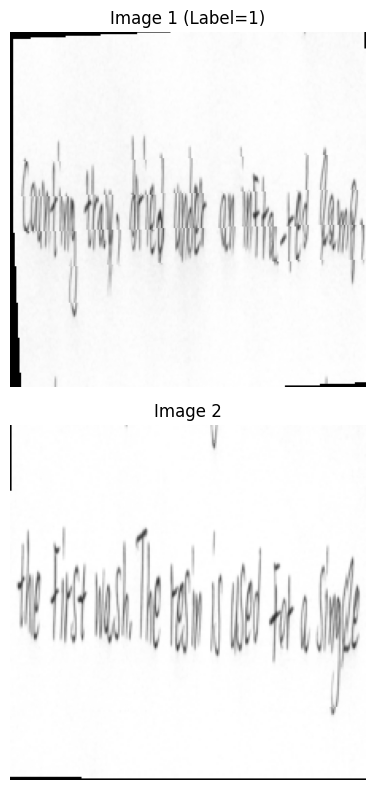

In [19]:
img1, img2, label = train_dataset[3]

print(f"Lbael: {label}")
print(f"Size img1: {img1.shape}")
print(f"Size img2: {img2.shape}")

plt.figure(figsize=(10, 8))

plt.subplot(2, 1, 1)
plt.imshow(img1[0], cmap='gray')
plt.title(f"Image 1 (Label={label})")
plt.axis('off')

plt.subplot(2, 1, 2)
plt.imshow(img2[0], cmap='gray')
plt.title("Image 2")
plt.axis('off')

plt.tight_layout()
plt.show()

In [20]:
labels=[]

for i in range(len(train_dataset)):
  labels.append(train_dataset[i][2])

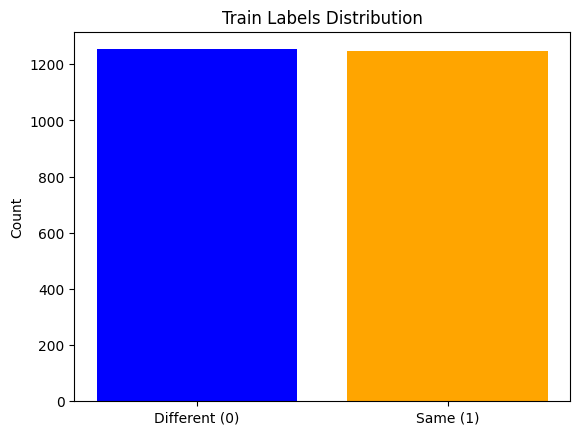

In [21]:
counts = [labels.count(0), labels.count(1)]

plt.bar(['Different (0)', 'Same (1)'], counts, color=['blue', 'orange'])
plt.ylabel('Count')
plt.title('Train Labels Distribution')
plt.show()

In [30]:
# creating DataLoader
train_loader = DataLoader(
    dataset=train_dataset,
    batch_size=8,
    shuffle=True,
    num_workers=0,
    pin_memory=True
)

val_loader = DataLoader(
    dataset=val_dataset,
    batch_size=8,
    shuffle=False,
    num_workers=0,
    pin_memory=True
)

Let's create class for our model. The class has freeze_mode parameter (aggressive or moderate), in aggressive mode we freeze all layer except for the last one, in moderate except for 2 lasts.For training we use Contrastive loss+BCE

In [24]:
class SiameseNetwork(nn.Module):
    def __init__(self, embedding_size=256, freeze_mode="aggressive"):
        super(SiameseNetwork, self).__init__()

        # Load pretrained ResNet-50
        backbone = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V1)

        # Adapt first layer for single channel
        original_conv1 = backbone.conv1
        backbone.conv1 = nn.Conv2d(1, 64, kernel_size=7, stride=2, padding=3, bias=False)
        backbone.conv1.weight.data = original_conv1.weight.data.mean(dim=1, keepdim=True)

        # Remove final FC layer
        self.resnet = nn.Sequential(*list(backbone.children())[:-1])

        # Freeze layers based on mode
        if freeze_mode == "aggressive":
            # Freeze all layers
            for param in self.resnet.parameters():
                param.requires_grad = False

            # Unfreeze layer4 (index 7) and conv1 (index 0)
            # layer4 parameters are under index 7
            for name, param in self.resnet.named_parameters():
                if name.startswith('7.'):  # layer4
                    param.requires_grad = True

            # Unfreeze conv1 (index 0)
            for param in self.resnet[0].parameters():
                param.requires_grad = True

        elif freeze_mode == "moderate":
            # Freeze all layers first
            for param in self.resnet.parameters():
                param.requires_grad = False

            # Unfreeze layer3 (index 6) and layer4 (index 7)
            for name, param in self.resnet.named_parameters():
                if name.startswith('6.') or name.startswith('7.'):  # layer3 and layer4
                    param.requires_grad = True

            # Unfreeze conv1 (index 0)
            for param in self.resnet[0].parameters():
                param.requires_grad = True

        elif freeze_mode == "none":
            # All layers trainable
            pass

        # Embedding head
        self.embedding = nn.Sequential(
            nn.Linear(2048, 1024),
            nn.ReLU(inplace=True),
            nn.Dropout(0.5),
            nn.Linear(1024, embedding_size)
        )

        # Classifier head
        self.classifier = nn.Linear(embedding_size, 1)

        self.embedding_size = embedding_size

        # Print statistics
        total = sum(p.numel() for p in self.parameters())
        trainable = sum(p.numel() for p in self.parameters() if p.requires_grad)
        print(f"Freeze mode: {freeze_mode}")
        print(f"Total parameters: {total:,}")
        print(f"Trainable parameters: {trainable:,} ({100*trainable/total:.1f}%)")

    def forward_one(self, x):
        x = self.resnet(x)
        x = x.view(x.size(0), -1)
        x = self.embedding(x)
        return F.normalize(x, p=2, dim=1)

    def forward(self, x1, x2):
        out1 = self.forward_one(x1)
        out2 = self.forward_one(x2)
        distance = torch.abs(out1 - out2)
        logits = self.classifier(distance).squeeze(1)
        return logits, out1, out2

In [25]:
class ContrastiveLoss(nn.Module):
    """Contrastive loss"""

    def __init__(self, margin=1.0):
        super(ContrastiveLoss, self).__init__()
        self.margin = margin

    def forward(self, output1, output2, label):
        # Eucledian distance
        distance = F.pairwise_distance(output1, output2)

        loss = label * torch.pow(distance, 2) / 2
        loss += (1 - label) * torch.pow(torch.clamp(self.margin - distance, min=0.0), 2) / 2

        return loss.mean()

In [27]:
def train_model(
    model,
    train_loader,
    val_loader,
    epochs=50,
    lr=0.001,
    device=None,
    save_path='best_model.pth',
    weight_decay=0.01
):
    """Training Siamese network with fixed contrastive loss"""

    if device is None:
        device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

    # Move model to device
    model = model.to(device)

    # Optimizer and scheduler
    optimizer = optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='min', factor=0.5, patience=2, threshold = 0.01
    )

    # Loss functions
    contrastive_loss = ContrastiveLoss(margin=1.0)
    bce_loss = nn.BCEWithLogitsLoss()

    # History tracking
    history = {
        'train_loss': [], 'val_loss': [],
        'train_acc': [], 'val_acc': [],
        'train_roc_auc': [], 'val_roc_auc': [],
        'lr': []
    }
    best_val_roc_auc = 0.0

    for epoch in range(epochs):
        # training
        model.train()
        train_loss = 0.0
        train_correct = 0
        train_total = 0
        train_labels = []
        train_preds = []


        pbar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs} [Train]")
        for img1, img2, labels in pbar:
            img1 = img1.to(device)
            img2 = img2.to(device)
            labels = labels.float().to(device)

            optimizer.zero_grad()
            logits, emb1, emb2 = model(img1, img2)

            loss_contrastive = contrastive_loss(emb1, emb2, labels)
            loss_bce = bce_loss(logits, labels)
            loss = loss_contrastive + loss_bce

            loss.backward()
            optimizer.step()

            train_loss += loss.item()
            probs = torch.sigmoid(logits)
            predicted = (probs > 0.5).float()
            train_correct += (predicted == labels).sum().item()
            train_total += labels.size(0)

            train_labels.extend(labels.cpu().numpy())
            train_preds.extend(probs.detach().cpu().numpy())  # use probs for ROC-AUC

            pbar.set_postfix({
                'loss': f'{loss.item():.4f}',
                'acc': f'{train_correct/train_total:.3f}'
                }
            )

        train_acc = train_correct / train_total
        train_loss_avg = train_loss / len(train_loader)
        train_roc_auc = roc_auc_score(train_labels, train_preds)


        # Validation
        model.eval()
        val_loss = 0.0
        val_correct = 0
        val_total = 0
        val_labels = []
        val_preds = []


        with torch.no_grad():
            for img1, img2, labels in tqdm(val_loader, desc=f"Epoch {epoch+1}/{epochs} [Val]"):
                img1 = img1.to(device)
                img2 = img2.to(device)
                labels = labels.float().to(device)

                logits, emb1, emb2 = model(img1, img2)

                loss_contrastive = contrastive_loss(emb1, emb2, labels)
                loss_bce = bce_loss(logits, labels)
                loss = loss_contrastive + 0.05 * loss_bce

                val_loss += loss.item()

                probs = torch.sigmoid(logits)
                predicted = (probs > 0.5).float()
                val_correct += (predicted == labels).sum().item()
                val_total += labels.size(0)

                val_labels.extend(labels.cpu().numpy())
                val_preds.extend(probs.cpu().numpy())

        val_acc = val_correct / val_total
        val_loss_avg = val_loss / len(val_loader)
        val_roc_auc = roc_auc_score(val_labels, val_preds)

        # Update scheduler
        scheduler.step(val_loss_avg)

        # Save history
        history['train_loss'].append(train_loss_avg)
        history['val_loss'].append(val_loss_avg)
        history['train_acc'].append(train_acc)
        history['val_acc'].append(val_acc)
        history['train_roc_auc'].append(train_roc_auc)
        history['val_roc_auc'].append(val_roc_auc)
        history['lr'].append(optimizer.param_groups[0]['lr'])

        # Print results
        print(f"\nEpoch {epoch+1}/{epochs}")
        print(f"  Train Loss: {train_loss_avg:.4f}, Train Acc: {train_acc:.4f}, ROC-AUC: {train_roc_auc:.4f}")
        print(f"  Val Loss:   {val_loss_avg:.4f}, Val Acc:   {val_acc:.4f}, ROC-AUC: {val_roc_auc:.4f}")
        print(f"  LR: {optimizer.param_groups[0]['lr']:.6f}")

        # Save best model by ROC-AUC
        if val_roc_auc > best_val_roc_auc:
            best_val_roc_auc = val_roc_auc
            torch.save({
                'epoch': epoch,
                'model_state_dict': model.state_dict(),
                'optimizer_state_dict': optimizer.state_dict(),
                'val_acc': val_acc,
                'val_roc_auc': val_roc_auc
            }, save_path)
            print(f"Model saved. Val Acc: {val_acc:.4f}, Val ROC-AUC: {val_roc_auc:.4f}")

    return history

In [31]:
model = SiameseNetwork(embedding_size=256, freeze_mode='aggressive')
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
# Train
history = train_model(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    epochs=30,
    lr=0.001,
    device=device,
    save_path='best_model_scratch.pth',
    weight_decay=0.0001)

print(f"\nBest Val ROC-AUC: {max(history['val_roc_auc'])*100:.2f}%")

Freeze mode: aggressive
Total parameters: 25,862,593
Trainable parameters: 17,328,705 (67.0%)


Epoch 1/30 [Val]: 100%|██████████| 250/250 [00:30<00:00,  8.28it/s]



Epoch 1/30
  Train Loss: 0.7809, Train Acc: 0.5790, ROC-AUC: 0.6542
  Val Loss:   0.1641, Val Acc:   0.6615, ROC-AUC: 0.7026
  LR: 0.001000
Model saved. Val Acc: 0.6615, Val ROC-AUC: 0.7026


Epoch 2/30 [Val]: 100%|██████████| 250/250 [00:30<00:00,  8.26it/s]



Epoch 2/30
  Train Loss: 0.7349, Train Acc: 0.6474, ROC-AUC: 0.6903
  Val Loss:   0.1505, Val Acc:   0.6545, ROC-AUC: 0.7324
  LR: 0.001000
Model saved. Val Acc: 0.6545, Val ROC-AUC: 0.7324


...


Epoch 28/30
  Train Loss: 0.3834, Train Acc: 0.8640, ROC-AUC: 0.9265
  Val Loss:   0.0764, Val Acc:   0.7825, ROC-AUC: 0.9296
  LR: 0.000250


Epoch 29/30 [Val]: 100%|██████████| 250/250 [00:29<00:00,  8.52it/s]



Epoch 29/30
  Train Loss: 0.3684, Train Acc: 0.8778, ROC-AUC: 0.9322
  Val Loss:   0.0686, Val Acc:   0.7695, ROC-AUC: 0.9411
  LR: 0.000250


Epoch 30/30 [Val]: 100%|██████████| 250/250 [00:29<00:00,  8.51it/s]


Epoch 30/30
  Train Loss: 0.3572, Train Acc: 0.8770, ROC-AUC: 0.9360
  Val Loss:   0.0734, Val Acc:   0.7700, ROC-AUC: 0.9389
  LR: 0.000250

Best Val ROC-AUC: 94.17%


In [32]:
history

{'train_loss': [0.7809354301452637,
  0.7348730766296386,
  0.7163281270027161,
  0.7028797885417938,
  0.7028358509540558,
  0.6909475461483001,
  0.6667073874950409,
  0.6444055172920227,
  0.6360838857412339,
  0.6173368205308915,
  0.6086444485664367,
  0.599099353313446,
  0.5864189198970795,
  0.5804681009054184,
  0.5525487507343292,
  0.5210051944494247,
  0.4804761971473694,
  0.47947741750478745,
  0.467487678360939,
  0.43993395763635634,
  0.4318051590204239,
  0.41269012047052384,
  0.4071416397571564,
  0.3891939423263073,
  0.3879851976156235,
  0.37201633293628694,
  0.36838928085565564,
  0.3834280654549599,
  0.36844753229022026,
  0.3572142431855202],
 'val_loss': [0.16413540995121,
  0.1504627005085349,
  0.17597739799320697,
  0.16529704362154007,
  0.13730259388312696,
  0.13441307251155377,
  0.12718756613135337,
  0.12516148564219476,
  0.12045656871795654,
  0.11082375260442495,
  0.10780071854963899,
  0.10418073455989361,
  0.10756989806890488,
  0.1009335319

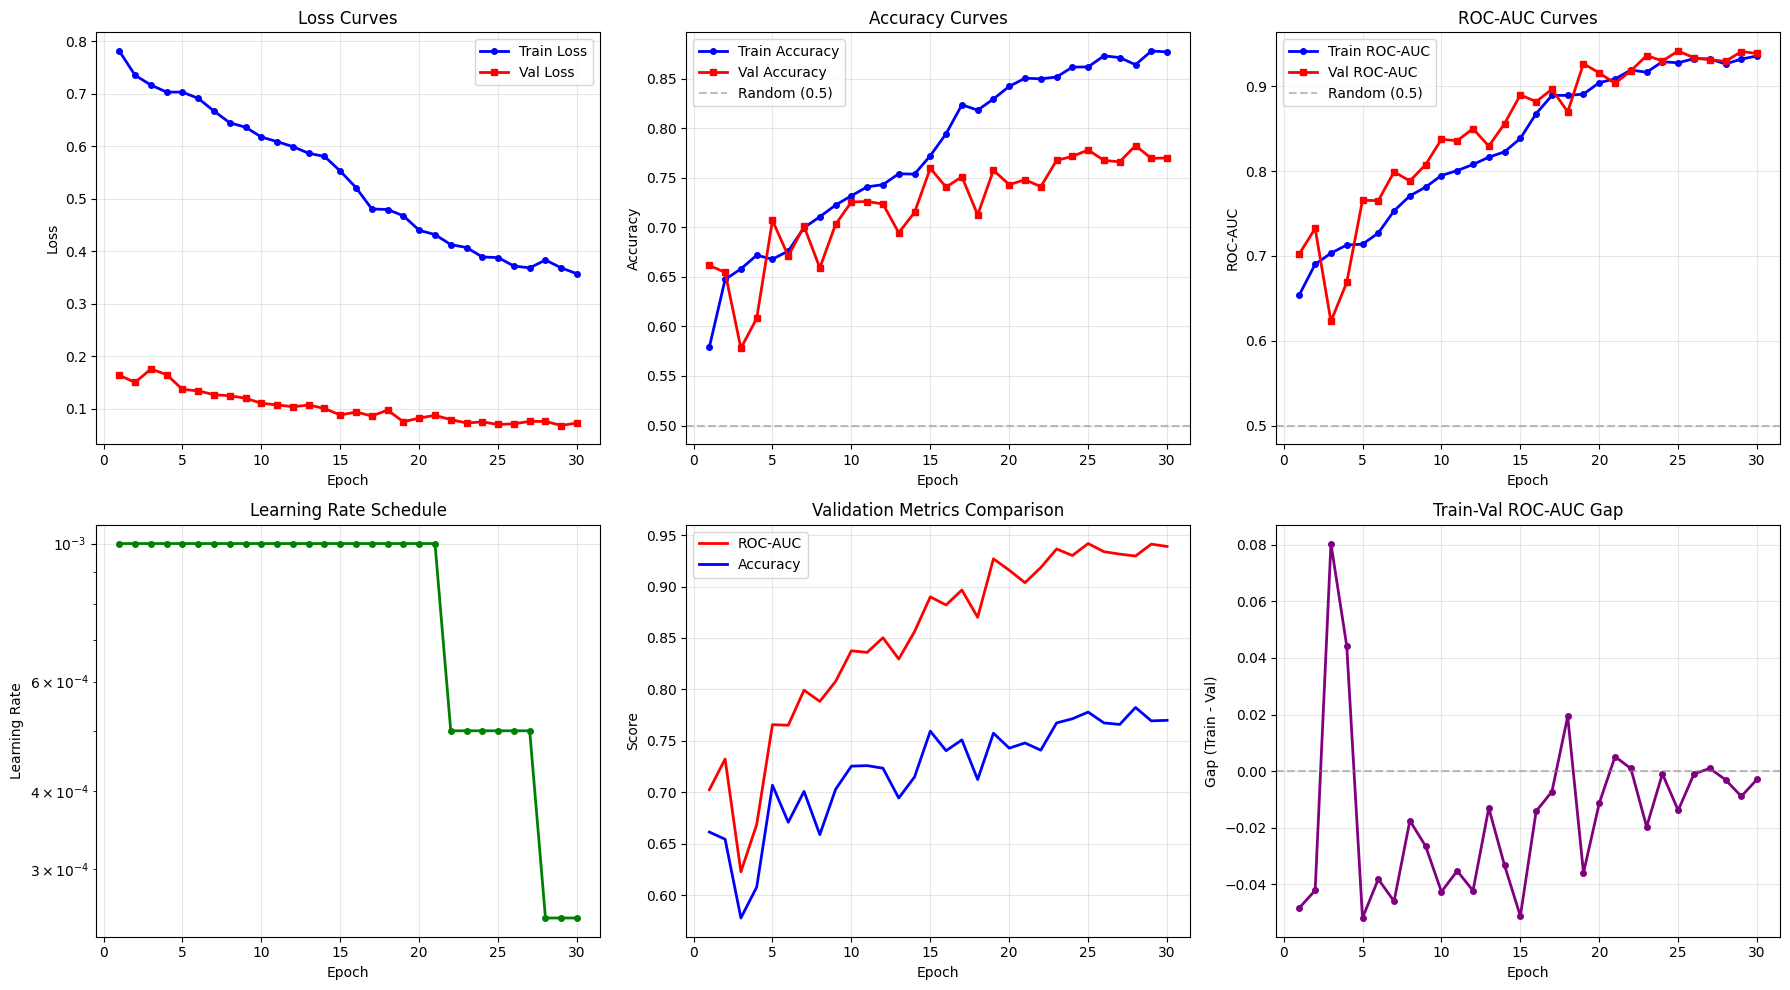

In [33]:
epochs = range(1, len(history['train_loss']) + 1)

train_loss = history['train_loss']
val_loss = history['val_loss']
train_acc = history['train_acc']
val_acc = history['val_acc']
train_roc_auc = history['train_roc_auc']
val_roc_auc = history['val_roc_auc']
lr = history['lr']

# Create figure with 2x3 subplots
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# 1. Loss Curves
axes[0, 0].plot(epochs, train_loss, 'b-o', label='Train Loss', linewidth=2, markersize=4)
axes[0, 0].plot(epochs, val_loss, 'r-s', label='Val Loss', linewidth=2, markersize=4)
axes[0, 0].set_xlabel('Epoch')
axes[0, 0].set_ylabel('Loss')
axes[0, 0].set_title('Loss Curves')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# 2. Accuracy Curves
axes[0, 1].plot(epochs, train_acc, 'b-o', label='Train Accuracy', linewidth=2, markersize=4)
axes[0, 1].plot(epochs, val_acc, 'r-s', label='Val Accuracy', linewidth=2, markersize=4)
axes[0, 1].axhline(y=0.5, color='gray', linestyle='--', alpha=0.5, label='Random (0.5)')
axes[0, 1].set_xlabel('Epoch')
axes[0, 1].set_ylabel('Accuracy')
axes[0, 1].set_title('Accuracy Curves')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# 3. ROC-AUC Curves
axes[0, 2].plot(epochs, train_roc_auc, 'b-o', label='Train ROC-AUC', linewidth=2, markersize=4)
axes[0, 2].plot(epochs, val_roc_auc, 'r-s', label='Val ROC-AUC', linewidth=2, markersize=4)
axes[0, 2].axhline(y=0.5, color='gray', linestyle='--', alpha=0.5, label='Random (0.5)')
axes[0, 2].set_xlabel('Epoch')
axes[0, 2].set_ylabel('ROC-AUC')
axes[0, 2].set_title('ROC-AUC Curves')
axes[0, 2].legend()
axes[0, 2].grid(True, alpha=0.3)

# 4. Learning Rate Schedule
axes[1, 0].plot(epochs, lr, 'g-o', linewidth=2, markersize=4)
axes[1, 0].set_xlabel('Epoch')
axes[1, 0].set_ylabel('Learning Rate')
axes[1, 0].set_title('Learning Rate Schedule')
axes[1, 0].set_yscale('log')
axes[1, 0].grid(True, alpha=0.3)

# 5. Combined Validation Metrics
axes[1, 1].plot(epochs, val_roc_auc, 'r-', label='ROC-AUC', linewidth=2)
axes[1, 1].plot(epochs, val_acc, 'b-', label='Accuracy', linewidth=2)
axes[1, 1].set_xlabel('Epoch')
axes[1, 1].set_ylabel('Score')
axes[1, 1].set_title('Validation Metrics Comparison')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

# 6. Train-Val Gap (ROC-AUC difference)
gap = [train_roc_auc[i] - val_roc_auc[i] for i in range(len(epochs))]
axes[1, 2].plot(epochs, gap, 'purple', marker='o', linewidth=2, markersize=4)
axes[1, 2].axhline(y=0, color='gray', linestyle='--', alpha=0.5)
axes[1, 2].set_xlabel('Epoch')
axes[1, 2].set_ylabel('Gap (Train - Val)')
axes[1, 2].set_title('Train-Val ROC-AUC Gap')
axes[1, 2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('training_metrics.png', dpi=150, bbox_inches='tight')
plt.show()

In [34]:
model_not_freezed = SiameseNetwork(embedding_size=256, freeze_mode=None)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
# Train
history = train_model(
    model=model_not_freezed,
    train_loader=train_loader,
    val_loader=val_loader,
    epochs=30,
    lr=0.001,
    device=device,
    save_path='best_model_not_freezed.pth')

print(f"\nBest Val ROC-AUC: {max(history['val_roc_auc'])*100:.2f}%")

Freeze mode: None
Total parameters: 25,862,593
Trainable parameters: 25,862,593 (100.0%)


Epoch 1/30 [Val]: 100%|██████████| 250/250 [00:30<00:00,  8.31it/s]



Epoch 1/30
  Train Loss: 0.8205, Train Acc: 0.5108, ROC-AUC: 0.5154
  Val Loss:   0.1876, Val Acc:   0.6145, ROC-AUC: 0.7278
  LR: 0.001000
Model saved. Val Acc: 0.6145, Val ROC-AUC: 0.7278


Epoch 2/30 [Val]: 100%|██████████| 250/250 [00:29<00:00,  8.36it/s]



Epoch 2/30
  Train Loss: 0.8201, Train Acc: 0.5200, ROC-AUC: 0.5230
  Val Loss:   0.2791, Val Acc:   0.4995, ROC-AUC: 0.5952
  LR: 0.001000


...


Epoch 28/30
  Train Loss: 0.4646, Train Acc: 0.8310, ROC-AUC: 0.8893
  Val Loss:   0.0809, Val Acc:   0.7785, ROC-AUC: 0.9043
  LR: 0.000125


Epoch 29/30 [Val]: 100%|██████████| 250/250 [00:29<00:00,  8.40it/s]



Epoch 29/30
  Train Loss: 0.4475, Train Acc: 0.8374, ROC-AUC: 0.8985
  Val Loss:   0.0824, Val Acc:   0.7620, ROC-AUC: 0.9094
  LR: 0.000125
Model saved. Val Acc: 0.7620, Val ROC-AUC: 0.9094


Epoch 30/30 [Val]: 100%|██████████| 250/250 [00:29<00:00,  8.34it/s]


Epoch 30/30
  Train Loss: 0.4355, Train Acc: 0.8454, ROC-AUC: 0.9036
  Val Loss:   0.0836, Val Acc:   0.7885, ROC-AUC: 0.9045
  LR: 0.000125

Best Val ROC-AUC: 90.94%


In [ ]:
history

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

epochs = range(1, len(history['train_loss']) + 1)

# 1. Loss Curves
axes[0, 0].plot(epochs, history['train_loss'], 'b-o', label='Train Loss', linewidth=2, markersize=4)
axes[0, 0].plot(epochs, history['val_loss'], 'r-s', label='Val Loss', linewidth=2, markersize=4)
axes[0, 0].set_xlabel('Epoch')
axes[0, 0].set_ylabel('Loss')
axes[0, 0].set_title('Loss Curves')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# 2. ROC-AUC Curves
axes[0, 1].plot(epochs, history['train_roc_auc'], 'b-o', label='Train ROC-AUC', linewidth=2, markersize=4)
axes[0, 1].plot(epochs, history['val_roc_auc'], 'r-s', label='Val ROC-AUC', linewidth=2, markersize=4)
axes[0, 1].axhline(y=0.5, color='gray', linestyle='--', alpha=0.5, label='Random (0.5)')
axes[0, 1].set_xlabel('Epoch')
axes[0, 1].set_ylabel('ROC-AUC')
axes[0, 1].set_title('ROC-AUC Curves')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# 3. Accuracy Curves
axes[1, 0].plot(epochs, history['train_acc'], 'b-o', label='Train Accuracy', linewidth=2, markersize=4)
axes[1, 0].plot(epochs, history['val_acc'], 'r-s', label='Val Accuracy', linewidth=2, markersize=4)
axes[1, 0].axhline(y=0.5, color='gray', linestyle='--', alpha=0.5, label='Random (0.5)')
axes[1, 0].set_xlabel('Epoch')
axes[1, 0].set_ylabel('Accuracy')
axes[1, 0].set_title('Accuracy Curves')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# 4. Learning Rate Schedule
axes[1, 1].plot(epochs, history['lr'], 'g-o', linewidth=2, markersize=4)
axes[1, 1].set_xlabel('Epoch')
axes[1, 1].set_ylabel('Learning Rate')
axes[1, 1].set_title('Learning Rate Schedule')
axes[1, 1].set_yscale('log')
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('training_metrics_moderate.png', dpi=150, bbox_inches='tight')
plt.show()


